In [5]:
# ============================================
# 1. Setup
# ============================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)
print("torch:", torch.__version__)

device: cuda
torch: 2.11.0+cu128


In [6]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

print(os.path.exists("/content/drive/MyDrive"))
print(os.listdir("/content/drive")[:10])

True
['MyDrive', 'Othercomputers', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [8]:
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

SPLIT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理/03_患者選定/COVID19_固定患者split_1277.csv"
)

PNG_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR/01_前処理/processed_png_1277"
)

TRAINING_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR/04_Training"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os

files = sorted(os.listdir(TRAINING_DIR))

for f in files:
    if "AugB_LR1e-5_seed42_weighted" in f:
        print(f)

AugB_LR1e-5_seed42_weighted_best.pth
AugB_LR1e-5_seed42_weighted_history.csv


In [10]:
# ============================================
# 3. Best checkpoint を読み込む
# ============================================

CHECKPOINT_PATH = os.path.join(
    TRAINING_DIR,
    "AugB_LR1e-5_seed42_weighted_best.pth"
)

model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 1)
model = model.to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

print("checkpoint keys:", checkpoint.keys())

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Checkpoint loaded successfully.")

checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'val_roc_auc', 'val_pr_auc', 'val_loss', 'condition_name', 'seed', 'lr', 'pos_weight'])
Checkpoint loaded successfully.


In [11]:
print("condition_name :", checkpoint["condition_name"])
print("epoch          :", checkpoint["epoch"])
print("val_roc_auc    :", checkpoint["val_roc_auc"])
print("val_pr_auc     :", checkpoint["val_pr_auc"])
print("val_loss       :", checkpoint["val_loss"])
print("seed           :", checkpoint["seed"])
print("lr             :", checkpoint["lr"])
print("pos_weight     :", checkpoint["pos_weight"])

condition_name : AugB_LR1e-5_seed42_weighted
epoch          : 12
val_roc_auc    : 0.848966613672496
val_pr_auc     : 0.5606217053146204
val_loss       : 0.857040524482727
seed           : 42
lr             : 1e-05
pos_weight     : 6.562962962962963


In [12]:
# ============================================
# 4. Evaluation用 Dataset / DataLoader
# ============================================

# 評価時は augmentation なし
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CXRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        patient_id = row["Subject ID"]
        label = float(row["true_label"])

        img_path = os.path.join(
            self.img_dir,
            f"{patient_id}.png"
        )

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32), patient_id


# split読み込み
split_df = pd.read_csv(SPLIT_CSV)

val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

val_dataset = CXRDataset(
    val_df,
    PNG_DIR,
    transform=eval_transform
)

test_dataset = CXRDataset(
    test_df,
    PNG_DIR,
    transform=eval_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Validation:", len(val_dataset))
print("Test      :", len(test_dataset))

print("Val deaths :", int(val_df["true_label"].sum()))
print("Test deaths:", int(test_df["true_label"].sum()))

Validation: 128
Test      : 128
Val deaths : 17
Test deaths: 17


In [13]:
# ============================================
# 5. Validation予測と閾値決定
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

def predict_probs(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []
    all_ids = []

    with torch.no_grad():
        for images, labels, patient_ids in loader:
            images = images.to(device)

            logits = model(images).squeeze(1)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_ids.extend(patient_ids)

    return (
        np.asarray(all_labels),
        np.asarray(all_probs),
        np.asarray(all_ids)
    )


# Validationのみで予測
val_y, val_prob, val_ids = predict_probs(
    model,
    val_loader,
    device
)

print("Validation n:", len(val_y))
print("Deaths:", int(val_y.sum()))

print("Val ROC-AUC:",
      roc_auc_score(val_y, val_prob))

print("Val PR-AUC:",
      average_precision_score(val_y, val_prob))


# Youden index
fpr, tpr, thresholds = roc_curve(val_y, val_prob)

youden = tpr - fpr
best_idx = np.argmax(youden)

VAL_THRESHOLD = thresholds[best_idx]

print("\n=== Validation threshold ===")
print("Threshold   :", VAL_THRESHOLD)
print("Sensitivity :", tpr[best_idx])
print("Specificity :", 1 - fpr[best_idx])
print("Youden index:", youden[best_idx])

Validation n: 128
Deaths: 17
Val ROC-AUC: 0.848966613672496
Val PR-AUC: 0.5606217053146204

=== Validation threshold ===
Threshold   : 0.5699251
Sensitivity : 0.7058823529411765
Specificity : 0.8648648648648649
Youden index: 0.5707472178060413


In [14]:
# ============================================
# 6. Final Test evaluation
# ============================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

test_y, test_prob, test_ids = predict_probs(
    model,
    test_loader,
    device
)

# AUC系
test_roc_auc = roc_auc_score(test_y, test_prob)
test_pr_auc = average_precision_score(test_y, test_prob)

# Validationで固定した閾値を適用
test_pred = (test_prob >= VAL_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(
    test_y,
    test_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = accuracy_score(test_y, test_pred)
precision = precision_score(test_y, test_pred)

print("=== Final Test ===")
print("n            :", len(test_y))
print("Deaths       :", int(test_y.sum()))
print("ROC-AUC      :", test_roc_auc)
print("PR-AUC       :", test_pr_auc)
print("Threshold    :", VAL_THRESHOLD)
print("Sensitivity  :", sensitivity)
print("Specificity  :", specificity)
print("Accuracy     :", accuracy)
print("Precision    :", precision)

print("\nConfusion matrix")
print("TN:", tn, "FP:", fp)
print("FN:", fn, "TP:", tp)

=== Final Test ===
n            : 128
Deaths       : 17
ROC-AUC      : 0.9072602013778485
PR-AUC       : 0.6229264898057557
Threshold    : 0.5699251
Sensitivity  : 0.7058823529411765
Specificity  : 0.9369369369369369
Accuracy     : 0.90625
Precision    : 0.631578947368421

Confusion matrix
TN: 104 FP: 7
FN: 5 TP: 12


In [15]:
# ============================================
# 7. Test ROC-AUC 95% CI
# Stratified bootstrap
# ============================================

from sklearn.metrics import roc_auc_score
import numpy as np

N_BOOTSTRAP = 10000
rng = np.random.default_rng(42)

pos_idx = np.where(test_y == 1)[0]
neg_idx = np.where(test_y == 0)[0]

bootstrap_aucs = []

for _ in range(N_BOOTSTRAP):

    # 死亡例・生存例をそれぞれ復元抽出
    boot_pos = rng.choice(
        pos_idx,
        size=len(pos_idx),
        replace=True
    )

    boot_neg = rng.choice(
        neg_idx,
        size=len(neg_idx),
        replace=True
    )

    boot_idx = np.concatenate([boot_pos, boot_neg])

    auc = roc_auc_score(
        test_y[boot_idx],
        test_prob[boot_idx]
    )

    bootstrap_aucs.append(auc)

bootstrap_aucs = np.asarray(bootstrap_aucs)

ci_lower = np.percentile(bootstrap_aucs, 2.5)
ci_upper = np.percentile(bootstrap_aucs, 97.5)

print("=== Test ROC-AUC ===")
print(f"ROC-AUC : {test_roc_auc:.4f}")
print(f"95% CI  : {ci_lower:.4f} - {ci_upper:.4f}")
print(f"Bootstrap repetitions: {N_BOOTSTRAP}")

=== Test ROC-AUC ===
ROC-AUC : 0.9073
95% CI  : 0.8357 - 0.9629
Bootstrap repetitions: 10000


In [16]:
# ============================================
# Save ALL final Task A evaluation results
# ============================================

import os
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    roc_curve
)

# --------------------------------------------
# 1. 保存先
# --------------------------------------------
EVAL_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "05_Evaluation"
)
os.makedirs(EVAL_DIR, exist_ok=True)


# ============================================
# 2. Validation結果を再計算
# ============================================

val_roc_auc = roc_auc_score(val_y, val_prob)
val_pr_auc = average_precision_score(val_y, val_prob)

fpr_val, tpr_val, thresholds_val = roc_curve(val_y, val_prob)
youden_val = tpr_val - fpr_val
best_idx = np.argmax(youden_val)

val_threshold = float(thresholds_val[best_idx])
val_sensitivity = float(tpr_val[best_idx])
val_specificity = float(1 - fpr_val[best_idx])
val_youden = float(youden_val[best_idx])


# ============================================
# 3. Test結果を再計算
# ============================================

test_roc_auc = roc_auc_score(test_y, test_prob)
test_pr_auc = average_precision_score(test_y, test_prob)

test_pred = (test_prob >= val_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    test_y,
    test_pred
).ravel()

test_sensitivity = tp / (tp + fn)
test_specificity = tn / (tn + fp)
test_accuracy = accuracy_score(test_y, test_pred)
test_precision = precision_score(test_y, test_pred)


# ============================================
# 4. Test患者別予測結果
# ============================================

test_pred_df = pd.DataFrame({
    "Subject ID": test_ids,
    "true_label": test_y.astype(int),
    "prob_death": test_prob,
    "pred_label": test_pred
})

test_pred_df["correct"] = (
    test_pred_df["true_label"] ==
    test_pred_df["pred_label"]
).astype(int)

test_pred_df["model_name"] = "CXR_ResNet18"

patient_pred_path = os.path.join(
    EVAL_DIR,
    "TaskA_CXR_Test患者別予測結果.csv"
)

test_pred_df.to_csv(
    patient_pred_path,
    index=False
)


# ============================================
# 5. 最終評価サマリー
# ============================================

summary_df = pd.DataFrame([{
    # Model
    "model_name": "CXR_ResNet18",
    "checkpoint": "AugB_LR1e-5_seed42_weighted_best.pth",
    "best_epoch": 12,
    "seed": 42,
    "initial_lr": 1e-5,
    "pos_weight": 886 / 135,

    # Validation
    "val_n": len(val_y),
    "val_deaths": int(np.sum(val_y)),
    "val_roc_auc": val_roc_auc,
    "val_pr_auc": val_pr_auc,
    "threshold_method": "Youden index",
    "val_threshold": val_threshold,
    "val_sensitivity": val_sensitivity,
    "val_specificity": val_specificity,
    "val_youden_index": val_youden,

    # Test
    "test_n": len(test_y),
    "test_deaths": int(np.sum(test_y)),
    "test_roc_auc": test_roc_auc,
    "test_roc_auc_ci_lower": ci_lower,
    "test_roc_auc_ci_upper": ci_upper,
    "test_roc_auc_ci_method": "Stratified bootstrap percentile",
    "bootstrap_repetitions": 10000,
    "test_pr_auc": test_pr_auc,
    "test_threshold": val_threshold,
    "test_sensitivity": test_sensitivity,
    "test_specificity": test_specificity,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,

    # Confusion matrix
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp)
}])

summary_path = os.path.join(
    EVAL_DIR,
    "TaskA_CXR_最終評価サマリー.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


# ============================================
# 6. Bootstrap distribution保存
# ============================================

bootstrap_df = pd.DataFrame({
    "bootstrap_iteration": np.arange(
        1,
        len(bootstrap_aucs) + 1
    ),
    "roc_auc": bootstrap_aucs
})

bootstrap_path = os.path.join(
    EVAL_DIR,
    "TaskA_CXR_ROCAUC_bootstrap_10000.csv"
)

bootstrap_df.to_csv(
    bootstrap_path,
    index=False
)


# ============================================
# 7. 保存結果確認
# ============================================

print("=== Saved Task A final evaluation ===")
print("Patient predictions:")
print(patient_pred_path)

print("\nEvaluation summary:")
print(summary_path)

print("\nBootstrap ROC-AUC:")
print(bootstrap_path)

print("\n=== Final values ===")
print(f"Val ROC-AUC  : {val_roc_auc:.6f}")
print(f"Val PR-AUC   : {val_pr_auc:.6f}")
print(f"Threshold    : {val_threshold:.7f}")

print(f"\nTest ROC-AUC : {test_roc_auc:.6f}")
print(f"95% CI       : {ci_lower:.4f} - {ci_upper:.4f}")
print(f"Test PR-AUC  : {test_pr_auc:.6f}")
print(f"Sensitivity  : {test_sensitivity:.6f}")
print(f"Specificity  : {test_specificity:.6f}")
print(f"Accuracy     : {test_accuracy:.6f}")
print(f"Precision    : {test_precision:.6f}")
print(f"TN/FP/FN/TP  : {tn}/{fp}/{fn}/{tp}")

=== Saved Task A final evaluation ===
Patient predictions:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/05_Evaluation/TaskA_CXR_Test患者別予測結果.csv

Evaluation summary:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/05_Evaluation/TaskA_CXR_最終評価サマリー.csv

Bootstrap ROC-AUC:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/05_Evaluation/TaskA_CXR_ROCAUC_bootstrap_10000.csv

=== Final values ===
Val ROC-AUC  : 0.848967
Val PR-AUC   : 0.560622
Threshold    : 0.5699251

Test ROC-AUC : 0.907260
95% CI       : 0.8357 - 0.9629
Test PR-AUC  : 0.622926
Sensitivity  : 0.705882
Specificity  : 0.936937
Accuracy     : 0.906250
Precision    : 0.631579
TN/FP/FN/TP  : 104/7/5/12


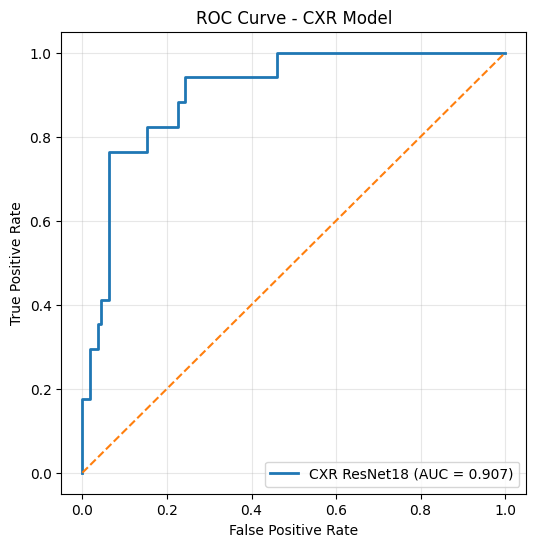

ROC data saved:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/05_Evaluation/TaskA_CXR_Test_ROC_curve_data.csv

ROC figure saved:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/05_Evaluation/TaskA_CXR_Test_ROC_curve.png

ROC-AUC = 0.9073
95% CI = 0.8357 - 0.9629


In [17]:
# ============================================
# Save Task A ROC curve
# ============================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve
fpr, tpr, thresholds = roc_curve(test_y, test_prob)
test_auc = roc_auc_score(test_y, test_prob)

# ROC座標も保存
roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
})

roc_csv_path = os.path.join(
    EVAL_DIR,
    "TaskA_CXR_Test_ROC_curve_data.csv"
)

roc_df.to_csv(
    roc_csv_path,
    index=False
)

# 図
plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"CXR ResNet18 (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CXR Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

roc_png_path = os.path.join(
    EVAL_DIR,
    "TaskA_CXR_Test_ROC_curve.png"
)

plt.savefig(
    roc_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC data saved:")
print(roc_csv_path)

print("\nROC figure saved:")
print(roc_png_path)

print(f"\nROC-AUC = {test_auc:.4f}")
print(f"95% CI = {ci_lower:.4f} - {ci_upper:.4f}")